In [58]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt

In [59]:
def create_node_graph_dict(directory):
    node_id_to_name = {}
    node_graph = {}
    node_cnt = 0
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if 'List of neighbors' in line:
                    d = json.loads(line)
                    node_graph[d['node_id']] = d.get('neighbors', [])
                    if d['node_id'] not in node_id_to_name:
                        node_id_to_name[d['node_id']] = f"node_{node_cnt}"
                        node_cnt += 1

    return node_id_to_name, node_graph

In [60]:
def build_directed_graph(node_names, graph):
    """
    Scans all files in `directory`, extracts nodes and neighbors, and builds a NetworkX DiGraph.
    """

    G = nx.DiGraph()

    for node, neighbors in graph.items():
        node_name = node_names[node]  
        G.add_node(node_name)
        for nbr in neighbors:
            if nbr in node_names:
                nbr_name = node_names[nbr]
            else:
                nbr_name = nbr
            G.add_node(nbr_name)
            G.add_edge(node_name, nbr_name)

    return G

In [61]:
def visualize_directed_graph(G, figsize=(12, 12), with_labels=True):
    # Project to undirected for consistent layout
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=figsize)

    # Separate edges by reciprocity
    solid_edges = []  # bidirectional
    dashed_edges = []  # one-way
    for u, v in G.edges():
        if G.has_edge(v, u):
            # ensure each is drawn only once
            if (v, u) not in solid_edges:
                solid_edges.append((u, v))
        else:
            dashed_edges.append((u, v))

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=300)
    if with_labels:
        nx.draw_networkx_labels(G, pos)

    # Draw bidirectional edges as solid undirected
    if solid_edges:
        nx.draw_networkx_edges(
            G.to_undirected(), pos,
            edgelist=solid_edges,
            style='solid',
            arrows=False
        )
    # Draw one-way edges as dashed with arrows
    if dashed_edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=dashed_edges,
            style='dashed',
            arrows=True
        )

    plt.title("Directed Neighbor Graph (one-way edges dashed)")
    plt.axis('off')
    plt.show()

In [62]:
files = "./logs-backup-20250726-192442"

In [63]:
nodes, graph = create_node_graph_dict(files)

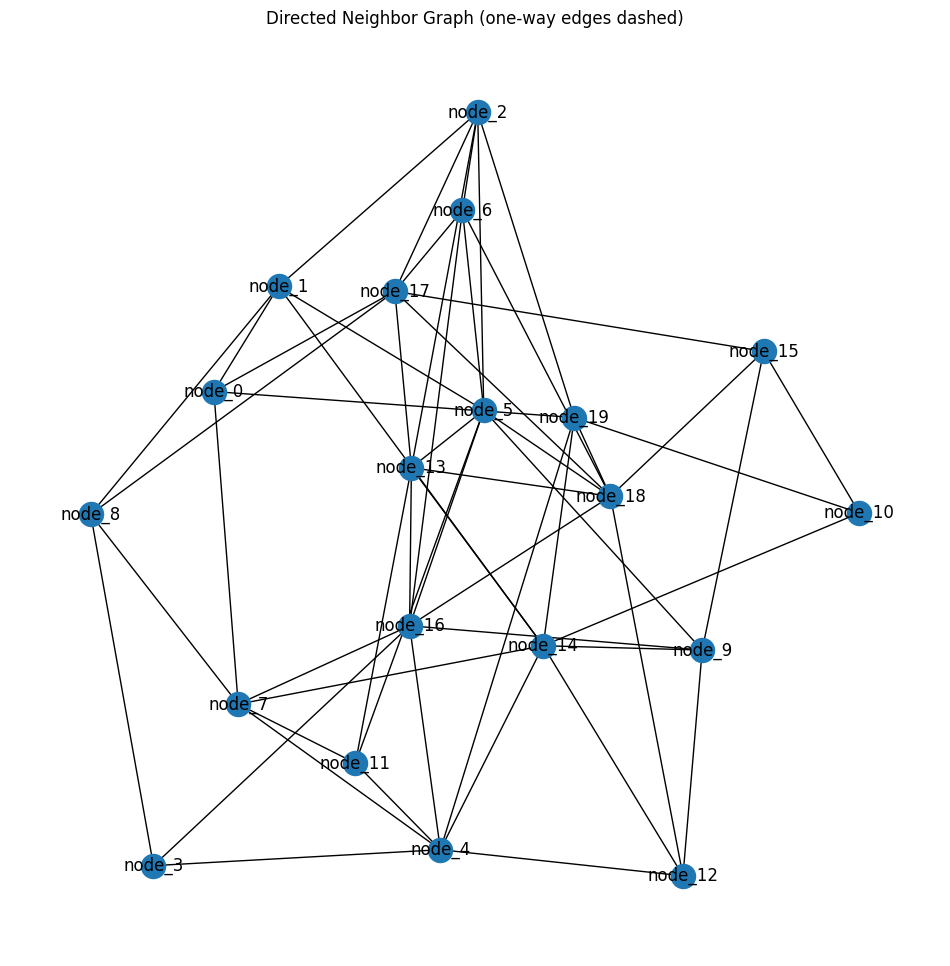

Number of connected components: 1
Component 1 (size 20): {'node_6', 'node_2', 'node_16', 'node_9', 'node_13', 'node_11', 'node_15', 'node_1', 'node_12', 'node_19', 'node_3', 'node_5', 'node_17', 'node_0', 'node_14', 'node_4', 'node_7', 'node_18', 'node_8', 'node_10'}
Diameter of component 1: 3


In [64]:
nodes, graph = create_node_graph_dict(files)
G = build_directed_graph(nodes, graph)

# Visualize directed graph
visualize_directed_graph(G)

# Analyze undirected projection for components and diameter
U = G.to_undirected()
comps = list(nx.connected_components(U))
print(f"Number of connected components: {len(comps)}")
for i, comp in enumerate(comps, 1):
    print(f"Component {i} (size {len(comp)}): {comp}")

for i, comp in enumerate(comps, 1):
    if len(comp) > 1:
        subU = U.subgraph(comp)
        diam = nx.diameter(subU)
        print(f"Diameter of component {i}: {diam}")
    else:
        print(f"Component {i} has a single node; diameter undefined.")

In [65]:
def analyze_committee(directory):
    all_committees = {}
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if "Committee elected" in line:
                    d = json.loads(line)
                    node_id = d["node_id"]  
                    committee = d["committee"]
                    all_committees[node_id] = [id["ID"] for id in committee]
    return all_committees

analyze_committee(files)

{'12D3KooWStuGE2kGcpzwmXV8CG2Ndc2ePDqzjVm4YEmXiqTmtXbq': ['12D3KooWAs1NoDdSXsAnQoXJMVLm2S7tK23hC5h5cfqnkMiT3WpX',
  '12D3KooWSm9Rfb5JgHrpvjGh6zhHLxQgGxqRB8KggBuhoC3Gg2yN',
  '12D3KooWG6Kwv3zhE1FVerngiqc2HGEADWXAd2pXfUJ6JA8pUMLr'],
 '12D3KooWA5dHJrGj7Bqia4Q7WeiWARJWXg8feouhFhp2wDwt6Rxm': ['12D3KooWQiBAJRN6ofSsg38tVgzJAvNrNW79cJ2fJTrYCknds6Zo',
  '12D3KooWQM2LFDmzrYDgWZfapZPeXF3wRHRQh83NyFXDKHJJgDcQ',
  '12D3KooWStuGE2kGcpzwmXV8CG2Ndc2ePDqzjVm4YEmXiqTmtXbq'],
 '12D3KooWQM2LFDmzrYDgWZfapZPeXF3wRHRQh83NyFXDKHJJgDcQ': ['12D3KooWG6Kwv3zhE1FVerngiqc2HGEADWXAd2pXfUJ6JA8pUMLr',
  '12D3KooWDRx7nHbow5YXzgoZEQ2TU5qk2poM2hzvuEiJswEvpNJD',
  '12D3KooWAs1NoDdSXsAnQoXJMVLm2S7tK23hC5h5cfqnkMiT3WpX',
  '12D3KooWPkxBNQZAP4RXrngnH2sQKiH78j424k4ZkU9ADdWbKmRS'],
 '12D3KooWE3bE19VkjTUsy53vG7ft17AS8qx5UdhL8NHNU93rph1s': ['12D3KooWAZ6jSMTaqfQqGJwjYEynZWZSFmccNFxKX6uYUiymttfV',
  '12D3KooWQiBAJRN6ofSsg38tVgzJAvNrNW79cJ2fJTrYCknds6Zo'],
 '12D3KooWQ89jnuPnj5ZaSdXFxXQBSsU2wSaLTSJhruNDqe2Xruy4': ['12D3KooWSm9Rfb5Jg

In [66]:
from itertools import combinations
from collections import Counter

# 1. Suppose you’ve already built a dict mapping member → list of nodes:
member_to_nodes = analyze_committee(files)

# 2. Invert to get node → set of members
node_to_members = {}
for member, nodes in member_to_nodes.items():
    for n in nodes:
        node_to_members.setdefault(n, set()).add(member)

# 3. Member frequency (how many nodes each member appears in)
total_nodes = len(node_to_members)
freq = {m: len(ns) for m, ns in member_to_nodes.items()}
fraction = {m: cnt/total_nodes for m, cnt in freq.items()}

print("Member\tCount\tFraction")
for m in freq:
    print(f"{m}\t{freq[m]}\t{fraction[m]:.2f}")

# 4. Pairwise Jaccard similarity between every pair of nodes
def jaccard(a, b):
    ia = node_to_members[a] & node_to_members[b]
    ua = node_to_members[a] | node_to_members[b]
    return len(ia) / len(ua) if ua else 0

pairs = combinations(node_to_members, 2)
jac_values = []
print("\nNodeA\tNodeB\tJaccard")
for a, b in pairs:
    j = jaccard(a, b)
    jac_values.append(j)
    print(f"{a}\t{b}\t{j:.2f}")

# 5. Aggregate metric
avg_jaccard = sum(jac_values) / len(jac_values)
print(f"\nAverage pairwise Jaccard: {avg_jaccard:.2f}")

Member	Count	Fraction
12D3KooWStuGE2kGcpzwmXV8CG2Ndc2ePDqzjVm4YEmXiqTmtXbq	3	0.25
12D3KooWA5dHJrGj7Bqia4Q7WeiWARJWXg8feouhFhp2wDwt6Rxm	3	0.25
12D3KooWQM2LFDmzrYDgWZfapZPeXF3wRHRQh83NyFXDKHJJgDcQ	4	0.33
12D3KooWE3bE19VkjTUsy53vG7ft17AS8qx5UdhL8NHNU93rph1s	2	0.17
12D3KooWQ89jnuPnj5ZaSdXFxXQBSsU2wSaLTSJhruNDqe2Xruy4	3	0.25
12D3KooWFB94Eic4xMwdZb4AKCGTdn2x9dJFEyUww13n8qGq7GmJ	5	0.42
12D3KooWDRx7nHbow5YXzgoZEQ2TU5qk2poM2hzvuEiJswEvpNJD	4	0.33
12D3KooWSm9Rfb5JgHrpvjGh6zhHLxQgGxqRB8KggBuhoC3Gg2yN	3	0.25
12D3KooWQiBAJRN6ofSsg38tVgzJAvNrNW79cJ2fJTrYCknds6Zo	2	0.17
12D3KooWPZwiHE27bT4mX6AUdiXEeSfMM1zTTdsdN8tCZmMn9me3	2	0.17
12D3KooWQDUxWgN6aBjFgVf9FfNNGBtaQSU7K39nHwxh63EDti4Y	2	0.17
12D3KooWAXGkUWYiX39Dtiqai4TKdGedgcZ5ZwubfGeiCnT3V8ue	2	0.17
12D3KooWM7YZxBpDDNSzsAeE4pS2ZHfxA1pL1rZDbieAnhTRtgnr	1	0.08
12D3KooWPkxBNQZAP4RXrngnH2sQKiH78j424k4ZkU9ADdWbKmRS	4	0.33
12D3KooWRKiz8pSiT7tzhvWUAaxNBKh1EFvkgxq3ZSv45YXznXRv	4	0.33
12D3KooWLHqPmsRUMsPyzMLhsWuCB2yKiFVDDxF68CzJZr45zJmp	3	0.25
12D3KooWAZ6jSMTaqf